In [1]:
import numpy as np
import pandas as pd

In [2]:
import scipy as sp
import scipy.stats as stats

### Оценки центрального положения

In [3]:
data = np.random.randint(1, 100, 10000)
data

array([72, 91, 38, ..., 47, 23, 30], shape=(10000,))

In [4]:
weights = np.random.randint(1, 5, 10000)
weights

array([4, 1, 1, ..., 1, 2, 1], shape=(10000,))

#### Среднее

In [9]:
print(data.mean())

49.8414


In [10]:
print(data.sum() / len(data))

49.8414


#### Среднее взвешенное

In [11]:
print(np.average(data, weights=weights))

49.93763226192853


In [12]:
print((data * weights).sum() / weights.sum())

49.93763226192853


#### Медиана

In [14]:
print(np.median(data))

50.0


In [16]:
print(np.percentile(data, 50))

50.0


#### Взвешенная медиана

In [33]:
df = pd.DataFrame(data={'value': data, 'weight': weights})
df

,value,weight
0,72,4
1,91,1
2,38,1
3,36,3
4,53,2
...,...,...
9995,44,2
9996,95,1
9997,47,1
9998,23,2


In [34]:
df = df.sort_values(by='value')
df

,value,weight
3913,1,2
1907,1,1
7538,1,3
6913,1,2
7543,1,2
...,...,...
4733,99,1
1990,99,1
5642,99,4
4259,99,4


In [35]:
df['cum_weight'] = df['weight'].cumsum()

In [36]:
df

,value,weight,cum_weight
3913,1,2,2
1907,1,1,3
7538,1,3,6
6913,1,2,8
7543,1,2,10
...,...,...,...
4733,99,1,25032
1990,99,1,25033
5642,99,4,25037
4259,99,4,25041


In [37]:
df['cum_weight_share'] = df['cum_weight'] / df['weight'].sum()
df

,value,weight,cum_weight,cum_weight_share
3913,1,2,2,0.000080
1907,1,1,3,0.000120
7538,1,3,6,0.000240
6913,1,2,8,0.000319
7543,1,2,10,0.000399
...,...,...,...,...
4733,99,1,25032,0.999481
1990,99,1,25033,0.999521
5642,99,4,25037,0.999681
4259,99,4,25041,0.999840


In [39]:
df.loc[df['cum_weight_share'].between(0.4999, 0.5001, inclusive='both')]

,value,weight,cum_weight,cum_weight_share
493,50,3,12522,0.49998
5967,50,3,12525,0.50010


In [41]:
print(np.percentile(data, 50, method='inverted_cdf', weights=weights))

50


In [46]:
def weighted_median(data, weights):
    sorter = np.argsort(data)
    data_sorted = data[sorter]
    weights_sorted = weights[sorter]
    weights_cum = np.cumsum(weights_sorted)
    cutoff = 0.5 * weights_cum[-1]
    idx = np.searchsorted(weights_cum, cutoff)
    return data_sorted[idx], idx, cutoff

In [47]:
print(weighted_median(data, weights))

(np.int64(50), np.int64(5022), np.float64(12522.5))


#### Среднее усеченное

In [48]:
data

array([72, 91, 38, ..., 47, 23, 30], shape=(10000,))

In [49]:
data_sorted = np.sort(data)

In [50]:
data

array([72, 91, 38, ..., 47, 23, 30], shape=(10000,))

In [51]:
data_sorted

array([ 1,  1,  1, ..., 99, 99, 99], shape=(10000,))

In [54]:
def trimmed_mean(data, p_num):
    data_sorted = np.sort(data)
    return data_sorted[p_num: len(data_sorted) - p_num].mean()

In [55]:
print(trimmed_mean(data, 50))

49.83979797979798


In [56]:
def trimmed_mean_frac(data, p_frac):
    data_sorted = np.sort(data)
    idx = int(len(data_sorted) * p_frac)
    return data_sorted[idx: len(data_sorted) - idx].mean()

In [57]:
print(trimmed_mean_frac(data, 0.1))

49.80725


In [58]:
50/10000

0.005

In [59]:
print(trimmed_mean_frac(data, 0.005))

49.83979797979798


In [60]:
print(stats.trim_mean(data, 0.005))

49.83979797979798


In [61]:
data

array([72, 91, 38, ..., 47, 23, 30], shape=(10000,))

In [63]:
print(stats.trimboth(data, 0.005).mean())

49.83979797979798


In [64]:
data

array([72, 91, 38, ..., 47, 23, 30], shape=(10000,))

### Оценка вариабельности

#### Среднее абсолютное отклонение

In [65]:
data

array([72, 91, 38, ..., 47, 23, 30], shape=(10000,))

In [66]:
m = data.mean()

In [67]:
print(m)

49.8414


In [73]:
print(np.abs(data - m).mean())

24.85185376


In [74]:
print(np.abs(data - data.mean()).mean())

24.85185376


#### Медианное абсолютное отклонение от медианы

In [76]:
print(np.percentile(np.abs(data - np.percentile(data, 50)), 50))

25.0


In [77]:
print(np.median(np.abs(data - np.median(data))))

25.0


In [78]:
print(stats.median_abs_deviation(data))

25.0


#### Размах

In [79]:
print(data.max() - data.min())

98


#### Межквартильный размах

In [80]:
print(np.percentile(data, 75) - np.percentile(data, 25))

50.0


In [81]:
s = pd.Series(data)
s

0       72
1       91
2       38
3       36
4       53
        ..
9995    44
9996    95
9997    47
9998    23
9999    30
Length: 10000, dtype: int64

In [82]:
print(s.quantile(0.75) - s.quantile(0.25))

50.0


In [85]:
print(np.percentile(data, 75), s.quantile(0.75), sep=', ')

75.0, 75.0


#### Дисперсия и стандартное отклонение

In [91]:
print(data.var(ddof=1))

823.7430203420342


In [92]:
print(data.std(ddof=1))

28.700923684474585


In [93]:
print(np.sqrt(data.var(ddof=1)))

28.700923684474585


In [89]:
s = pd.Series(data)
s

0       72
1       91
2       38
3       36
4       53
        ..
9995    44
9996    95
9997    47
9998    23
9999    30
Length: 10000, dtype: int64

In [90]:
print(s.var())

823.7430203420377


In [94]:
print(s.std())

28.700923684474645


#### Коробочные диаграммы и другие визуализации

In [95]:
s = pd.Series(data)

<Axes: >

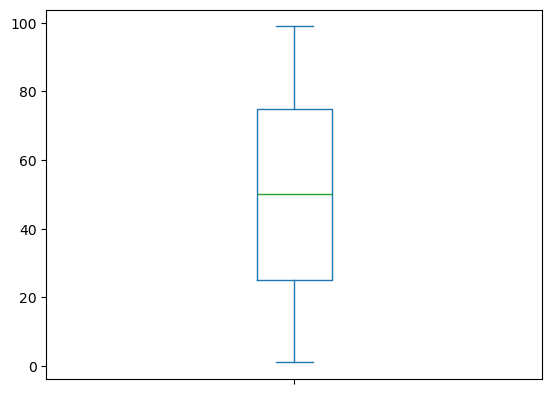

In [96]:
s.plot.box()

<Axes: ylabel='Frequency'>

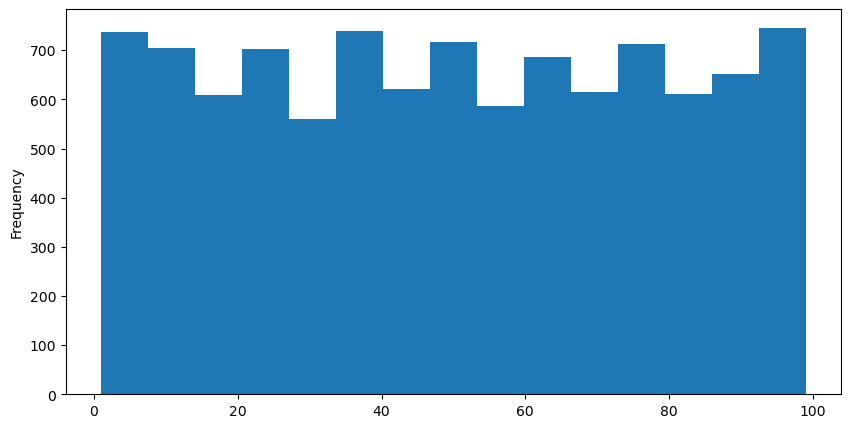

In [103]:
s.plot.hist(bins=15, figsize=(10, 5))

<Axes: ylabel='Density'>

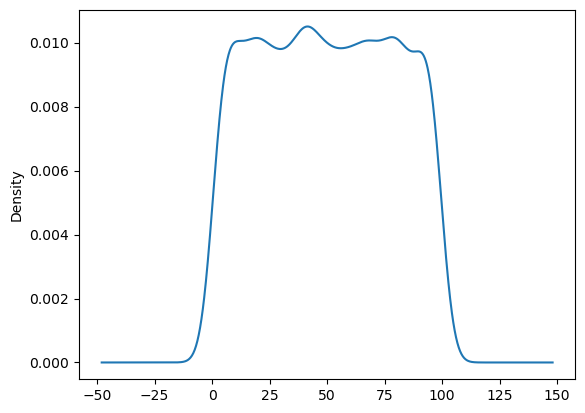

In [106]:
s.plot.density()

<Axes: ylabel='Density'>

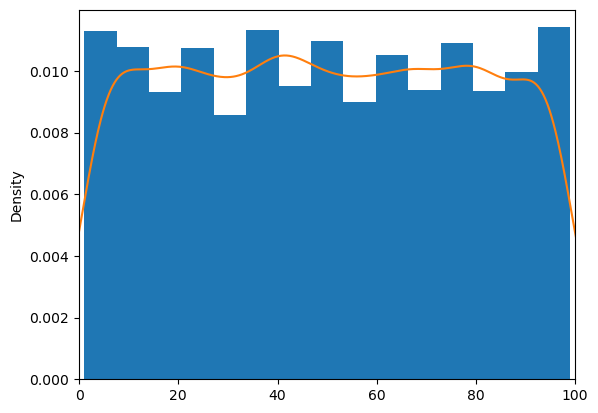

In [110]:
ax = s.plot.hist(density=True, xlim=[0, 100], bins=15)
s.plot.density(ax=ax)

#### Корреляция

In [111]:
df = pd.DataFrame(data={'value': data, 'weight': weights})
df.head()

,value,weight
0,72,4
1,91,1
2,38,1
3,36,3
4,53,2


In [112]:
df.corr()

,value,weight
value,1.000000,0.007514
weight,0.007514,1.000000


In [113]:
import seaborn as sns

<Axes: >

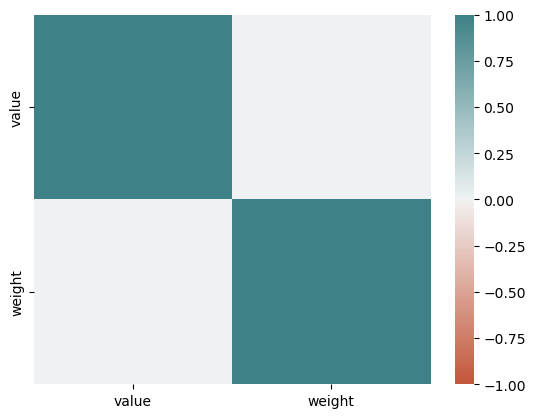

In [118]:
sns.heatmap(df.corr(), vmin=-1, vmax=1, cmap=sns.diverging_palette(20, 200, as_cmap=True))

<Axes: xlabel='weight', ylabel='value'>

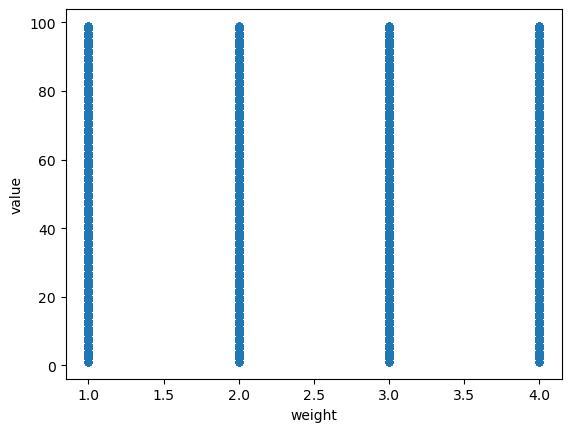

In [121]:
df.plot.scatter(x='weight', y='value')

<Axes: xlabel='weight', ylabel='value'>

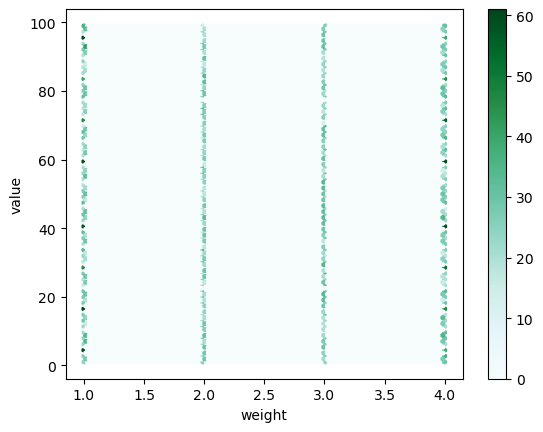

In [124]:
df.plot.hexbin(x='weight', y='value')

<Axes: xlabel='weight', ylabel='value'>

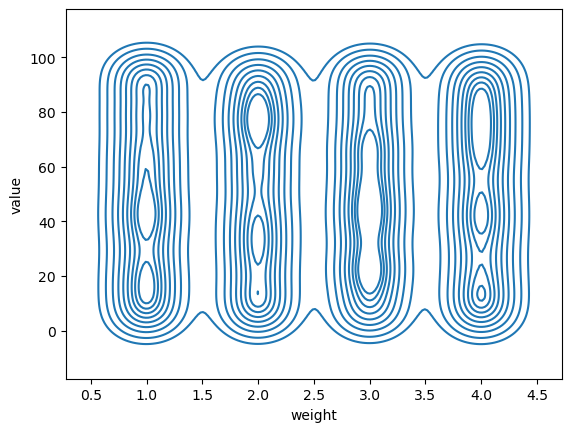

In [127]:
sns.kdeplot(x=df['weight'], y=df['value'])